<a href="https://colab.research.google.com/github/deduwkaa/Theory_and_Applications_of_Digital_Signal_Processing/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Завантаження файлу...
Файл успішно завантажено! Частота дискретизації: 44100 Гц
Виконуємо оверсамплінг з коефіцієнтом 64...


/tmp/ipykernel_3086/19421694.py:15: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, audio = wavfile.read(filename)


Генерація 1-бітного потоку (це може зайняти кілька секунд)...
Фільтрація потоку (Low-pass filter, f_c = 4000 Гц)...
Децимація (зменшення частоти дискретизації до початкової)...


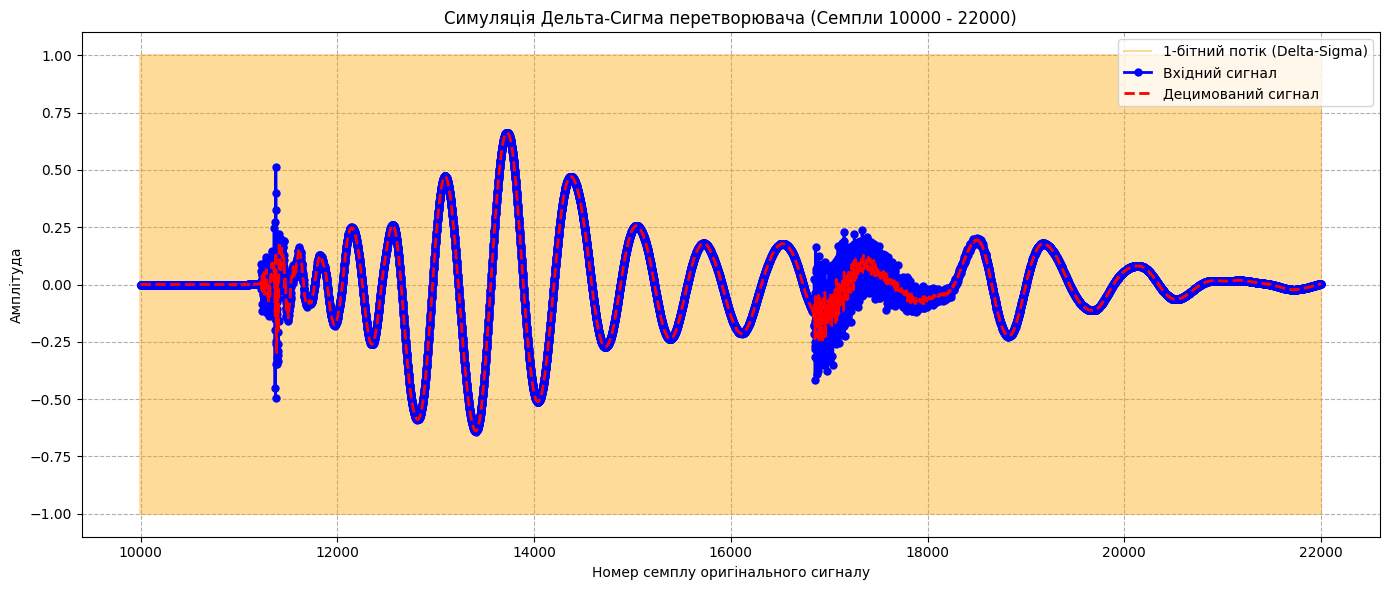

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import scipy.io.wavfile as wavfile
import urllib.request

# 1 & 2. Завантаження аудіо з GitHub
github_raw_url = "https://raw.githubusercontent.com/deduwkaa/Theory_and_Applications_of_Digital_Signal_Processing/main/418595__realdavidfloat__harder-kick-hat-odd-timing-120bpm-20.wav"
filename = "input_audio.wav"

print("Завантаження файлу...")
try:
    urllib.request.urlretrieve(github_raw_url, filename)
    fs, audio = wavfile.read(filename)
    print(f"Файл успішно завантажено! Частота дискретизації: {fs} Гц")
except Exception as e:
    print("Помилка завантаження. Генеруємо тестовий аудіосигнал (синусоїду 400 Гц)...")
    fs = 44100
    t_test = np.linspace(0, 1, fs, endpoint=False)
    audio = np.sin(2 * np.pi * 400 * t_test)

# Перетворюємо в моно і нормалізуємо амплітуду від -1 до 1
if len(audio.shape) > 1:
    audio = audio[:, 0]
audio = audio / np.max(np.abs(audio))

# Для швидкодії в Colab беремо лише першу 0.1 секунду аудіо
#audio = audio[:int(fs * 0.1)]

# 3. Авторська реалізація Дельта-Сигма перетворювача
OSRx = 64  # Коефіцієнт оверсамплінгу
print(f"Виконуємо оверсамплінг з коефіцієнтом {OSRx}...")

# Збільшуємо частоту дискретизації
audio_up = signal.resample_poly(audio, OSRx, 1)

print("Генерація 1-бітного потоку (це може зайняти кілька секунд)...")
N = len(audio_up)
bitstream = np.zeros(N)
integrator = 0.0
dac_out = 0.0

# Основний цикл дельта-сигма модулятора 1-го порядку
for i in range(N):
    # Додаємо різницю між вхідним сигналом та попереднім виходом
    integrator += audio_up[i] - dac_out
    # Квантуємо в 1 біт (1 або -1)
    dac_out = 1.0 if integrator >= 0 else -1.0
    bitstream[i] = dac_out

# 4. Фільтрація низькочастотним фільтром
fc = 4000  # Частота зрізу (f_c) в Гц
print(f"Фільтрація потоку (Low-pass filter, f_c = {fc} Гц)...")
fs_up = fs * OSRx
nyq_up = 0.5 * fs_up

# Створюємо фільтр Баттерворта 4-го порядку
b, a = signal.butter(4, fc / nyq_up, btype='low')
# Використовуємо filtfilt для фільтрації без фазового зсуву
filtered_stream = signal.filtfilt(b, a, bitstream)

# 5. Децимація сигналу
print("Децимація (зменшення частоти дискретизації до початкової)...")
# Просто беремо кожен OSRx-тий семпл
decimated_signal = filtered_stream[::OSRx]

# 6. Візуалізація результатів
# Задаємо ділянку (номери семплів) оригінального сигналу для відображення
start_sample = 10000
end_sample = 22000

# Створюємо осі часу (в семплах) для графіків
t_orig = np.arange(start_sample, end_sample)
# Для 1-бітного потоку вісь часу в OSRx разів щільніша
t_up = np.linspace(start_sample, end_sample, (end_sample - start_sample) * OSRx, endpoint=False)

plt.figure(figsize=(14, 6))

# 1-бітний потік (робимо його напівпрозорим помаранчевим)
plt.step(t_up, bitstream[start_sample*OSRx : end_sample*OSRx], 'orange', alpha=0.4, label='1-бітний потік (Delta-Sigma)', where='post')

# Оригінальний вхідний сигнал
plt.plot(t_orig, audio[start_sample:end_sample], 'b-o', label='Вхідний сигнал', linewidth=2, markersize=5)

# Відновлений (децимований) сигнал
plt.plot(t_orig, decimated_signal[start_sample:end_sample], 'r--', label='Децимований сигнал', linewidth=2)

plt.title(f'Симуляція Дельта-Сигма перетворювача (Семпли {start_sample} - {end_sample})')
plt.xlabel('Номер семплу оригінального сигналу')
plt.ylabel('Амплітуда')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()